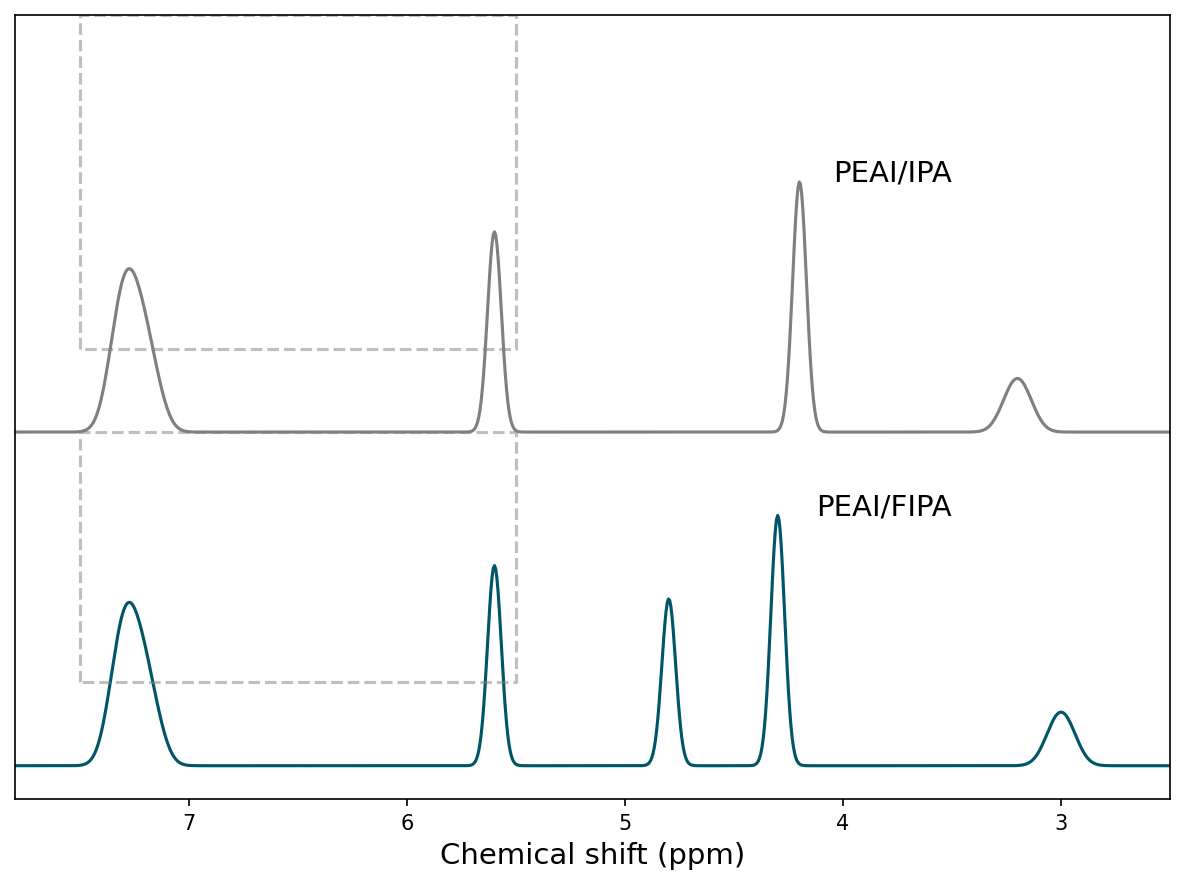

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
ppm = np.linspace(8, 2.5, 1000) # Reversed

def triplet(x, center, split, h):
    return h * (0.5*np.exp(-((x-(center-split))**2)/0.005) + 
                1.0*np.exp(-((x-center)**2)/0.005) + 
                0.5*np.exp(-((x-(center+split))**2)/0.005))

def doublet(x, center, split, h):
    return h * (1.0*np.exp(-((x-(center-split))**2)/0.005) + 
                1.0*np.exp(-((x-(center+split))**2)/0.005))

def singlet(x, center, h):
    return h * np.exp(-((x-center)**2)/0.002)

# 1. PEAI/IPA (Grey)
y_ipa = np.zeros_like(ppm)
y_ipa += triplet(ppm, 7.3, 0.05, 5) # Multiplet 7.3
y_ipa += triplet(ppm, 7.2, 0.05, 3) # Multiplet 7.2
y_ipa += singlet(ppm, 5.6, 12) # Sharp 5.6
y_ipa += singlet(ppm, 4.2, 15) # Sharp 4.2
y_ipa += triplet(ppm, 3.2, 0.05, 2) # Multiplet 3.2

# 2. PEAI/FIPA (Teal)
y_fipa = np.zeros_like(ppm)
y_fipa += triplet(ppm, 7.3, 0.05, 5) 
y_fipa += triplet(ppm, 7.2, 0.05, 3)
y_fipa += singlet(ppm, 5.6, 12) # Split? No looks singlet in main, doublet in inset
y_fipa += singlet(ppm, 4.8, 10) # Shifted
y_fipa += singlet(ppm, 4.3, 15)
y_fipa += triplet(ppm, 3.0, 0.05, 2)

# Offset
y_ipa += 20

# --- Plotting ---
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Plot
ax.plot(ppm, y_ipa, color='gray', lw=1.5)
ax.text(3.5, 35, 'PEAI/IPA', fontsize=14, ha='right')

ax.plot(ppm, y_fipa, color='#005566', lw=1.5)
ax.text(3.5, 15, 'PEAI/FIPA', fontsize=14, ha='right')

# Dashed boxes (Placeholders for Insets)
# Insets would be zoomed regions. I'll just draw boxes.
ax.plot([7.5, 7.5, 5.5, 5.5, 7.5], [25, 45, 45, 25, 25], '--', color='gray', alpha=0.5)
ax.plot([7.5, 7.5, 5.5, 5.5, 7.5], [5, 20, 20, 5, 5], '--', color='gray', alpha=0.5)

# Styling
ax.set_xlabel('Chemical shift (ppm)', fontsize=14)
ax.set_xlim(7.8, 2.5) # Reversed
ax.set_yticks([])
ax.set_ylim(-2, 45)

plt.tight_layout()
plt.show()
